# Case 6: heteroskedastic DPLQR epoch stability

Research question:
"Under Zhong and Wang (2024) Simulation II, deep Case 6,
at tau=0.5, does continuing the same DPLQR optimization
trajectory for more epochs cause the estimated parametric
coefficient theta_hat to drift away from the true
theta_0=(1,-1), even when the empirical check loss continues
to improve?"

This is a **finite-sample optimization stability experiment**, not a mathematical test of asymptotic consistency.

**Execution:** this notebook is supplied entirely unexecuted. Run with the repository's Python environment from the repository root or this experiment folder. The clearly marked Monte Carlo cell launches Q=50 replications at each n=1000,2000, up to 2000 epochs. No smoke test or tuning grid is included. To inspect saved results later, skip that cell. The optional oracle section is disabled by default and is independent of training.

For each (n, replication), all checkpoints lie on **one continuously trained model and one Adam optimizer**. Validation is diagnostic only. A restart restores model, masks, Adam moments/step counters and random-generator states at the latest saved epoch boundary; it does not restart a checkpoint as an independent fit. Exact resumption requires the same recorded software and CPU environment.

## 1. Imports and repository paths

Reuse `dqAux.py` directly. Read only selected helper definitions from the notebooks used by the September 11 Case 3 experiment; never execute their simulation cells. No R dependency is needed.

In [1]:
from pathlib import Path
from types import SimpleNamespace
from contextlib import contextmanager
from copy import deepcopy
import ast
import hashlib
import importlib.metadata
import json
import math
import os
import platform
import random
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.integrate import quad_vec
from sklearn.preprocessing import StandardScaler
import torch
from torchtuples import Model
import torchtuples as tt
from IPython.display import display

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "dqAux.py").is_file())
EXPERIMENT = ROOT / "results/2026-09-15_heteroskedastic_epoch_drift_case6"
NOTEBOOK = EXPERIMENT / "heteroskedastic_epoch_drift_case6.ipynb"
PREVIOUS = ROOT / "results/2026-09-11_asymptotic_normality_case3"
PREVIOUS_NOTEBOOK = PREVIOUS / "asymptotic_normality_case3.ipynb"
DGP_SOURCE = ROOT / "results/2026-09-04-homoscedastic-simulation/simulate_homoscedastic.ipynb"
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
bytecode_setting = sys.dont_write_bytecode
try:
    sys.dont_write_bytecode = True
    from dqAux import dqNetSparse, checkLoss
finally:
    sys.dont_write_bytecode = bytecode_setting

def selected_definitions(path, names):
    selected = {}
    for cell in json.loads(path.read_text(encoding="utf-8"))["cells"]:
        if cell["cell_type"] != "code":
            continue
        for node in ast.parse("".join(cell["source"])).body:
            if isinstance(node, (ast.FunctionDef, ast.ClassDef)) and node.name in names:
                if node.name in selected:
                    raise ValueError(f"Duplicate definition: {node.name}")
                selected[node.name] = node
    if set(selected) != set(names):
        raise ValueError(f"Missing definitions in {path}: {set(names) - set(selected)}")
    return [selected[name] for name in names]

REUSED_DGP_NAMES = ("seed_all", "nonlinear_truth", "clip_neural_weights", "tensor_pair")
REUSED_IO_NAMES = ("atomic_write", "run_lock")
helper_namespace = dict(np=np, torch=torch, random=random, os=os, json=json, platform=platform,
                        contextmanager=contextmanager)
for path, names in ((DGP_SOURCE, REUSED_DGP_NAMES), (PREVIOUS_NOTEBOOK, REUSED_IO_NAMES)):
    exec(compile(ast.Module(body=selected_definitions(path, names), type_ignores=[]),
                 str(path), "exec"), helper_namespace)
reused = SimpleNamespace(**{name: helper_namespace[name] for name in REUSED_DGP_NAMES})
atomic_write = helper_namespace["atomic_write"]
run_lock = helper_namespace["run_lock"]

## 2. Fixed experiment configuration

The saved Case 3 configuration supplies depth=2, width=32, minibatch=128, learning rate=0.005, seed convention and 80:20 split. The implementation is kept on CPU with one thread and deterministic algorithms.

**Optimizer detail:** Case 3 constructs \`torchtuples.Model\` with its default \`tt.optim.AdamW\` wrapper. In the installed implementation this wraps **\`torch.optim.Adam\`**, with betas **(0.9, 0.99)** and zero decoupled weight decay. We specify those same settings explicitly, rather than accidentally adopting PyTorch's different default second beta.

**Sparsity detail:** \`dqNetSparse\` applies the repository's random masks to its intermediate neural layers. The number of zeros is a binomial draw with probability 0.5; it is not forced to be exactly 50% in every row. Preserve this implementation, the input/output layers, ReLU, default dropout=1e-5 and the explicit linear-layer \`reset_parameters()\`.

**Weight truncation:** raw theta and primary losses are recorded on the live, untruncated trajectory. At each reported epoch the original \`clip_neural_weights\` is applied to a **deep copy** for additional post-fit loss diagnostics. It never clips theta or masks. Applying post-fit truncation to the live model at epoch 200 would alter the subsequent trajectory; therefore checkpoint copies alone are truncated. Both raw and truncated checkpoint snapshots are retained.

In [2]:
previous_config = json.loads((PREVIOUS / "run/run_config.json").read_text(encoding="utf-8"))
previous_identity = previous_config["identity"]
assert previous_identity["case"] == 3 and previous_identity["tau"] == 0.5

CASE, TAU = 6, 0.50
THETA_0 = np.array([1.0, -1.0])
Q = 50
N_LIST = (1000, 2000)
CHECKPOINT_EPOCHS = (200, 500, 1000, 2000)
MAX_EPOCHS = 2000
SAVE_EVERY = 50  # Epoch-boundary recovery snapshots; not additional scientific checkpoints.
HP = dict(previous_identity["hp"])
BASE_SEED = int(previous_identity["seed"])
TRAIN_FRACTION = float(previous_identity["train_fraction"])
THREADS = int(previous_identity["threads"])
DEVICE = "cpu"
ADAM_BETAS = (0.9, 0.99)
ADAM_EPS = 1e-8
OUTPUT_DIR = EXPERIMENT / "run"
RUN_ORACLE = False  # Optional post-estimation section only.

assert HP == dict(depth=2, width=32, batch_size=128, lr=0.005)
assert BASE_SEED == 20260904 and TRAIN_FRACTION == 0.8 and THREADS == 1
assert TAU == 0.5 and np.array_equal(THETA_0, [1.0, -1.0])
assert isinstance(Q, int) and Q >= 1
assert MAX_EPOCHS == max(CHECKPOINT_EPOCHS) and tuple(sorted(set(CHECKPOINT_EPOCHS))) == CHECKPOINT_EPOCHS
assert SAVE_EVERY > 0
torch.set_num_threads(THREADS)
torch.use_deterministic_algorithms(True)

def sha256_file(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

# Verify that the reused scientific sources match those recorded by Case 3.
for relative, digest in previous_identity["sources"].items():
    path = ROOT / Path(relative.replace("\\", "/"))
    if path in (ROOT / "dqAux.py", DGP_SOURCE):
        if sha256_file(path) != digest:
            raise ValueError(f"Source changed since Case 3: {relative}; inspect before using this configuration.")

def definition_digest(path, names):
    canonical = "\n".join(ast.dump(node, include_attributes=False) for node in selected_definitions(path, names))
    return hashlib.sha256(canonical.encode()).hexdigest()

def run_identity():
    notebook = json.loads(NOTEBOOK.read_text(encoding="utf-8"))
    implementation = "".join("".join(cell["source"]) for cell in notebook["cells"]
        if "case6_implementation" in cell.get("metadata", {}).get("tags", []))
    return dict(
        schema=1, case=CASE, tau=TAU, theta=THETA_0.tolist(),
        seed=BASE_SEED, train_fraction=TRAIN_FRACTION, hp=HP,
        n_list=list(N_LIST), checkpoint_epochs=list(CHECKPOINT_EPOCHS), max_epochs=MAX_EPOCHS,
        save_every=SAVE_EVERY, device=DEVICE, threads=THREADS, deterministic_algorithms=True,
        optimizer="tt.optim.AdamW wrapping torch.optim.Adam",
        adam_betas=list(ADAM_BETAS), adam_eps=ADAM_EPS, decoupled_weight_decay=0.0,
        continuous_trajectory=True, early_stopping=False, validation="diagnostic only",
        clipping="original helper on checkpoint copies only; raw live state always resumes",
        sigma_formula="0.2*x1 + Phi(mean(z-1)); published x1+x1 retained literally",
        theta_source="raw joint DPLQR check-loss optimization",
        source_sha256={"dqAux.py": sha256_file(ROOT / "dqAux.py"),
                       "reused_DGP_definitions": definition_digest(DGP_SOURCE, REUSED_DGP_NAMES),
                       "reused_Case3_IO_definitions": definition_digest(PREVIOUS_NOTEBOOK, REUSED_IO_NAMES)},
        implementation_sha256=hashlib.sha256(implementation.encode()).hexdigest(),
        versions={name: importlib.metadata.version(name) for name in
                  ("numpy", "pandas", "scipy", "scikit-learn", "torch", "torchtuples", "matplotlib")},
        python=platform.python_version(), platform=platform.platform(),
    )

IDENTITY = run_identity()
FINGERPRINT = hashlib.sha256(json.dumps(IDENTITY, sort_keys=True).encode()).hexdigest()

def prepare_run():
    output = OUTPUT_DIR.resolve()
    if EXPERIMENT.resolve() not in output.parents:
        raise ValueError("OUTPUT_DIR must be inside the new Case 6 experiment.")
    output.mkdir(parents=True, exist_ok=True)
    with run_lock(output):
        path = output / "run_config.json"
        if path.exists():
            old = json.loads(path.read_text(encoding="utf-8"))
            if old["identity"] != IDENTITY or old["fingerprint"] != FINGERPRINT:
                raise ValueError("Scientific settings/source/environment changed; use a new OUTPUT_DIR.")
            if Q < old["requested_Q"]:
                raise ValueError("Do not reduce Q in an existing run; use a fresh OUTPUT_DIR.")
            old.update(requested_Q=Q, expected_rows=len(N_LIST)*Q*len(CHECKPOINT_EPOCHS))
            atomic_write(path, old)
        else:
            if (output / "replications").exists() or (output / "raw_replications.csv").exists():
                raise ValueError("Existing outputs without matching configuration; use a fresh OUTPUT_DIR.")
            atomic_write(path, dict(identity=IDENTITY, fingerprint=FINGERPRINT, requested_Q=Q,
                status="configured", completed_rows=0, expected_rows=len(N_LIST)*Q*len(CHECKPOINT_EPOCHS)))
    return output

OUTPUT = prepare_run()
print(json.dumps(dict(**IDENTITY, requested_Q=Q, output=str(OUTPUT.relative_to(ROOT))), indent=2))

{
  "schema": 1,
  "case": 6,
  "tau": 0.5,
  "theta": [
    1.0,
    -1.0
  ],
  "seed": 20260904,
  "train_fraction": 0.8,
  "hp": {
    "depth": 2,
    "width": 32,
    "batch_size": 128,
    "lr": 0.005
  },
  "n_list": [
    1000,
    2000
  ],
  "checkpoint_epochs": [
    200,
    500,
    1000,
    2000
  ],
  "max_epochs": 2000,
  "save_every": 50,
  "device": "cpu",
  "threads": 1,
  "deterministic_algorithms": true,
  "optimizer": "tt.optim.AdamW wrapping torch.optim.Adam",
  "adam_betas": [
    0.9,
    0.99
  ],
  "adam_eps": 1e-08,
  "decoupled_weight_decay": 0.0,
  "continuous_trajectory": true,
  "early_stopping": false,
  "validation": "diagnostic only",
  "clipping": "original helper on checkpoint copies only; raw live state always resumes",
  "sigma_formula": "0.2*x1 + Phi(mean(z-1)); published x1+x1 retained literally",
  "theta_source": "raw joint DPLQR check-loss optimization",
  "source_sha256": {
    "dqAux.py": "99dc7ce752818cd59e4a8d8cc048d0a3752659f601503bea0b

## 3. Random seeds and exact restart state

Data seed = \`BASE_SEED + CASE*10_000_000 + n_total*1000 + replication\`.
Fit seed = data seed + \`round(tau*1_000_000)\`. Epoch is absent from both formulas.

The original helper seeds Python, NumPy and PyTorch. The DGP uses its own \`default_rng(data_seed)\`.
Recovery stores all training RNG states, not just the starting seed. The restored RNG is installed in
\`on_fit_start\`, after torchtuples' loader setup, so startup inspection of a minibatch does not perturb a resumed trajectory.

In [3]:
def capture_rng():
    state = np.random.get_state()
    return dict(
        python=random.getstate(),
        numpy=dict(algorithm=state[0], keys=state[1].tolist(), position=int(state[2]),
                   has_gauss=int(state[3]), cached_gaussian=float(state[4])),
        torch_cpu=torch.get_rng_state().clone(),
    )

def restore_rng(state):
    random.setstate(state["python"])
    saved = state["numpy"]
    np.random.set_state((saved["algorithm"], np.asarray(saved["keys"], dtype=np.uint32),
                        saved["position"], saved["has_gauss"], saved["cached_gaussian"]))
    torch.set_rng_state(state["torch_cpu"])

def seeds_for(n_total, replication):
    data_seed = BASE_SEED + CASE * 10_000_000 + int(n_total) * 1000 + int(replication)
    return data_seed, data_seed + int(round(TAU * 1_000_000))

## 4. Exact Gaussian-copula covariates

Draw a 10-dimensional normal with diagonal covariance 1 and all off-diagonals 0.5.
Transform with $2\Phi$, set $X_1=1\{\widetilde Z_9>1\}$, $X_2=\widetilde Z_{10}$ and
$Z=\widetilde Z_{1:8}$. Retain the raw latent $G_{1:8}$ internally for the optional oracle section.
This is the previous generator with the latent matrix retained; no alternative copula is introduced.

In [4]:
def generate_case6_covariates(n_total, rng):
    covariance = np.full((10, 10), 0.5)
    np.fill_diagonal(covariance, 1.0)
    latent = rng.multivariate_normal(np.zeros(10), covariance, size=n_total)
    z_tilde = 2 * norm.cdf(latent)
    z = z_tilde[:, :8]
    x = np.column_stack((z_tilde[:, 8] > 1, z_tilde[:, 9])).astype(float)
    return x, z, latent[:, :8]

## 5. Exact deep function, heteroskedastic scale, and split

Reuse the **vectorized original Case 3** \`nonlinear_truth(z, 3)\`, which implements
$$m(z)=0.61\left[
e^{z_1(1+z_2-\pi z_3z_4)/2}(z_5+0.2)
+\frac{z_5(z_4-0.3)}{|2z_4-1|+1}
+2\sin(z_5)|z_5z_6-0.6|+\log(z_6+z_7z_8)\right].$$

**Published expression followed literally:**
$$\sigma(x,z)=(x_1+x_1)/10+\Phi\left(\frac18\sum_{k=1}^8(z_k-1)\right).$$
The second $x_1$ is intentionally not changed to $x_2$.

Generate independent unscaled $\epsilon\sim t_3$ and
$Y=X^\top(1,-1)+m(Z)+\sigma(X,Z)\epsilon$.
The scale is positive, so the conditional median is exactly $X^\top(1,-1)+m(Z)$.

As in Case 3, the same data RNG draws the permutation **after the error draws**. Fit on the first
80% and validate on the rest. StandardScaler is fitted only to training Z; X and Y stay on their raw
scales. The data hash includes X, raw Z, Y, split order and retained latent values.

In [5]:
def case6_m(z_raw):
    return reused.nonlinear_truth(np.asarray(z_raw), 3)

def case6_sigma(x_raw, z_raw):
    x_raw, z_raw = np.asarray(x_raw), np.asarray(z_raw)
    scale = 0.2 * x_raw[:, 0] + norm.cdf(np.mean(z_raw - 1, axis=1))
    if not np.isfinite(scale).all() or np.any(scale <= 0):
        raise FloatingPointError("Case 6 scale must be positive and finite.")
    return scale

def make_case6(n_total, replication):
    data_seed, fit_seed = seeds_for(n_total, replication)
    rng = np.random.default_rng(data_seed)
    x, z, latent = generate_case6_covariates(n_total, rng)
    m = case6_m(z)
    sigma = case6_sigma(x, z)
    epsilon = rng.standard_t(df=3, size=n_total)
    y = x @ THETA_0 + m + sigma * epsilon
    order = rng.permutation(n_total)
    n_fit = int(TRAIN_FRACTION * n_total)
    tr, va = order[:n_fit], order[n_fit:]
    scaler = StandardScaler().fit(z[tr])
    digest = hashlib.sha256(b"".join(a.tobytes() for a in (x, z, y, order, latent))).hexdigest()
    if not np.isfinite(y).all():
        raise FloatingPointError("Non-finite generated response.")
    return SimpleNamespace(
        n_total=int(n_total), n_fit=n_fit, n_val=len(va), replication=int(replication),
        data_seed=data_seed, fit_seed=fit_seed, data_sha256=digest,
        x_train=x[tr], z_train=z[tr], y_train=y[tr], latent_train=latent[tr],
        x_val=x[va], z_val=z[va], y_val=y[va], latent_val=latent[va], scaler=scaler,
    )

## 6. Reused joint DPLQR model and check loss

The model is \`dqNetSparse(2, 8, ..., [2, 32], sparseRatio=0.5)\`, exactly as in Case 3.
Its linear layer and nonlinear network are optimized jointly by the original \`checkLoss(tau=0.5)\`.
No residualization, projection network, oracle weighting, or nuisance density is involved.

Full-sample checkpoint losses use eval mode (dropout disabled) and are weighted by actual batch
sizes. They are diagnostic evaluations of the current parameters, not averages of losses from
different parameter values encountered during an epoch. Additional clipped-copy losses follow the
previous post-fit nuisance truncation.

In [6]:
def new_model(fit_seed):
    reused.seed_all(fit_seed)
    net = dqNetSparse(2, 8, torch.zeros((1, 2), dtype=torch.float32),
                      [HP["depth"], HP["width"]], sparseRatio=0.5)
    net.linLinear.reset_parameters()  # Preserve Case 3's explicit theta initialization.
    optimizer = tt.optim.AdamW(lr=HP["lr"], betas=ADAM_BETAS, eps=ADAM_EPS,
                                decoupled_weight_decay=0.0)
    model = Model(net, checkLoss(tau=TAU), optimizer=optimizer, device=DEVICE)
    model.optimizer.set_lr(HP["lr"])
    assert isinstance(model.optimizer.optimizer, torch.optim.Adam)
    assert tuple(model.optimizer.param_groups[0]["betas"]) == ADAM_BETAS
    return model

def state_digest(net):
    digest = hashlib.sha256()
    for name, value in net.state_dict().items():
        digest.update(name.encode())
        digest.update(value.detach().cpu().contiguous().numpy().tobytes())
    return digest.hexdigest()

def full_check_loss(net, inputs, target):
    training = net.training
    net.eval()
    total = 0.0
    loss_function = checkLoss(tau=TAU)
    try:
        with torch.no_grad():
            for start in range(0, len(target), HP["batch_size"]):
                stop = min(start + HP["batch_size"], len(target))
                prediction = net(*(value[start:stop].to(DEVICE) for value in inputs))
                loss = loss_function(prediction, target[start:stop].to(DEVICE))
                total += float(loss) * (stop - start)
    finally:
        net.train(training)
    value = total / len(target)
    if not np.isfinite(value):
        raise FloatingPointError("Non-finite full-sample check loss.")
    return value

def make_checkpoint_row(model, data, epoch, updates, elapsed, inputs, targets, initialization_sha256):
    # Diagnostic evaluations must never perturb training randomness or parameters.
    rng = capture_rng()
    try:
        theta = model.net.linLinear.weight.detach().cpu().numpy().reshape(-1).astype(float)
        live_digest = state_digest(model.net)
        if not np.isfinite(theta).all():
            raise FloatingPointError("Non-finite theta.")
        clipped = deepcopy(model.net)
        reused.clip_neural_weights(clipped)
        np.testing.assert_array_equal(clipped.linLinear.weight.detach().cpu().numpy().reshape(-1), theta)
        row = dict(
            case=CASE, tau=TAU, n_total=data.n_total, n_fit=data.n_fit, n_val=data.n_val,
            replication=data.replication, seed=data.data_seed, data_seed=data.data_seed,
            fit_seed=data.fit_seed, data_sha256=data.data_sha256,
            initialization_sha256=initialization_sha256, epoch=int(epoch), optimizer_updates=int(updates),
            train_check_loss=full_check_loss(model.net, inputs[0], targets[0]),
            validation_check_loss=full_check_loss(model.net, inputs[1], targets[1]),
            train_check_loss_clipped=full_check_loss(clipped, inputs[0], targets[0]),
            validation_check_loss_clipped=full_check_loss(clipped, inputs[1], targets[1]),
            elapsed_time=float(elapsed),
        )
        for j in (1, 2):
            error = float(theta[j - 1] - THETA_0[j - 1])
            row.update({f"theta_hat_{j}": float(theta[j - 1]), f"theta0_{j}": float(THETA_0[j - 1]),
                        f"error_theta{j}": error, f"squared_error_theta{j}": error**2})
        assert state_digest(model.net) == live_digest
        return row, deepcopy(clipped.state_dict())
    finally:
        restore_rng(rng)

## 7. Continuous training loop with epoch checkpoints

A fresh replication invokes \`model.fit(..., epochs=2000)\` **once**. The callback observes the
same model at epochs 200, 500, 1000 and 2000, returning False throughout. Adam is never reset
between them. Standard per-epoch validation monitoring uses the same torchtuples fitting path as Case 3.

An interrupted process can reconstruct the seeded data and reload the latest **raw** model,
optimizer, masks and RNG states. It then invokes fit only for the remaining epochs. This is a
continuation of the saved trajectory, not a newly initialized checkpoint experiment.

Recovery snapshots occur every 50 completed epochs and at every scientific checkpoint. Work
after the most recent snapshot may be repeated after an interruption; already published checkpoint
rows are not erased. \`elapsed_time\` is cumulative active time through the checkpoint, including
diagnostic and saving overhead but excluding time while the process was stopped.

In [7]:
class ContinuousCheckpoints(tt.callbacks.Callback):
    def __init__(self, data, directory, inputs, targets, saved, initialization_sha256):
        self.data, self.directory = data, directory
        self.inputs, self.targets = inputs, targets
        self.saved = saved
        self.epoch = int(saved["epoch"]) if saved else 0
        self.updates = int(saved["optimizer_updates"]) if saved else 0
        self.rows = deepcopy(saved["rows"]) if saved else []
        self.elapsed_before = float(saved["elapsed_time"]) if saved else 0.0
        self.initialization_sha256 = initialization_sha256

    def on_fit_start(self):
        self.started = time.perf_counter()
        self.model.net.train()
        if self.saved is not None:
            # torchtuples has already inspected its loader. Undo startup RNG consumption.
            restore_rng(self.saved["rng"])
        self.optimizer_object = self.model.optimizer.optimizer
        return False

    def on_batch_end(self):
        if not torch.isfinite(self.model.batch_loss).item():
            raise FloatingPointError("Non-finite minibatch loss; retain the last safe snapshot.")
        self.updates += 1
        return False

    def on_epoch_end(self):
        self.epoch += 1
        assert self.model.optimizer.optimizer is self.optimizer_object
        assert self.updates == self.epoch * math.ceil(self.data.n_fit / HP["batch_size"])
        is_checkpoint = self.epoch in CHECKPOINT_EPOCHS
        clipped_state = None
        if is_checkpoint:
            row, clipped_state = make_checkpoint_row(
                self.model, self.data, self.epoch, self.updates,
                self.elapsed_before + time.perf_counter() - self.started,
                self.inputs, self.targets, self.initialization_sha256)
            if any(old["epoch"] == self.epoch for old in self.rows):
                raise ValueError("A scientific checkpoint was unexpectedly repeated.")
            self.rows.append(row)
        if is_checkpoint or self.epoch % SAVE_EVERY == 0 or self.epoch == MAX_EPOCHS:
            bundle = dict(
                fingerprint=FINGERPRINT, n_total=self.data.n_total, replication=self.data.replication,
                n_fit=self.data.n_fit, data_sha256=self.data.data_sha256,
                data_seed=self.data.data_seed, fit_seed=self.data.fit_seed,
                initialization_sha256=self.initialization_sha256, epoch=self.epoch,
                optimizer_updates=self.updates,
                elapsed_time=self.elapsed_before + time.perf_counter() - self.started,
                raw_model=self.model.net.state_dict(), optimizer=self.model.optimizer.state_dict(),
                rng=capture_rng(), rows=deepcopy(self.rows), clipped_model=clipped_state,
            )
            # Durable trajectory state is committed BEFORE rows are exposed in JSON/CSV.
            atomic_write(self.directory / "trajectory.pt", bundle, "torch")
            if clipped_state is not None:
                path = self.directory / f"clipped_epoch_{self.epoch:04d}.pt"
                if not path.exists():
                    atomic_write(path, dict(fingerprint=FINGERPRINT, epoch=self.epoch,
                        data_sha256=self.data.data_sha256, clipped_model=clipped_state), "torch")
            if is_checkpoint:
                publish_rows(self.directory, self.rows)
                export_raw_results()
                print(f"Saved n={self.data.n_total}, replication={self.data.replication}, epoch={self.epoch}")
        return False  # No early stopping or model selection.

    def on_fit_end(self):
        if self.epoch != MAX_EPOCHS:
            raise RuntimeError("The continuous fit did not finish its requested epoch budget.")
        assert self.updates == MAX_EPOCHS * math.ceil(self.data.n_fit / HP["batch_size"])
        return False

def fit_continuous(data, directory):
    directory.mkdir(parents=True, exist_ok=True)
    state_path = directory / "trajectory.pt"
    saved = torch.load(state_path, map_location="cpu", weights_only=True) if state_path.exists() else None
    if saved is not None:
        expected = dict(fingerprint=FINGERPRINT, n_total=data.n_total, replication=data.replication,
                        n_fit=data.n_fit, data_sha256=data.data_sha256,
                        data_seed=data.data_seed, fit_seed=data.fit_seed)
        if any(saved[key] != value for key, value in expected.items()):
            raise ValueError(f"Incompatible trajectory state: {state_path}")
        if not 0 <= saved["epoch"] <= MAX_EPOCHS:
            raise ValueError("Invalid recovery epoch.")
        assert saved["optimizer_updates"] == saved["epoch"] * math.ceil(data.n_fit / HP["batch_size"])
        assert sorted(row["epoch"] for row in saved["rows"]) == [e for e in CHECKPOINT_EPOCHS if e <= saved["epoch"]]
        # Repair outputs if a process stopped just after committing its trajectory state.
        clipped_path = directory / f"clipped_epoch_{saved['epoch']:04d}.pt"
        if saved.get("clipped_model") is not None and not clipped_path.exists():
            atomic_write(clipped_path, dict(fingerprint=FINGERPRINT, epoch=saved["epoch"],
                data_sha256=data.data_sha256, clipped_model=saved["clipped_model"]), "torch")
        publish_rows(directory, saved["rows"])
        export_raw_results()
        if saved["epoch"] == MAX_EPOCHS:
            return saved["rows"]
    elif any(directory.glob("result_epoch_*.json")):
        raise ValueError("Checkpoint rows exist without trajectory state; refusing an independent restart.")

    # One live model and Adam optimizer per uninterrupted run; a restart reloads their full states.
    model = new_model(data.fit_seed)
    initialization_sha256 = state_digest(model.net)
    if saved is not None:
        if initialization_sha256 != saved["initialization_sha256"]:
            raise ValueError("Initialization changed; use the recorded environment.")
        model.net.load_state_dict(saved["raw_model"])
        model.optimizer.load_state_dict(saved["optimizer"])
    train_x = reused.tensor_pair(data.x_train, data.scaler.transform(data.z_train))
    val_x = reused.tensor_pair(data.x_val, data.scaler.transform(data.z_val))
    train_y = torch.tensor(data.y_train[:, None], dtype=torch.float32)
    val_y = torch.tensor(data.y_val[:, None], dtype=torch.float32)
    observer = ContinuousCheckpoints(data, directory, (train_x, val_x), (train_y, val_y),
                                     saved, initialization_sha256)
    start_epoch = int(saved["epoch"]) if saved else 0
    model.fit(
        train_x, train_y, batch_size=HP["batch_size"], epochs=MAX_EPOCHS - start_epoch,
        callbacks=[observer], verbose=False, shuffle=True, num_workers=0,
        val_data=(val_x, val_y), val_batch_size=HP["batch_size"],
    )
    return observer.rows

## 8. Incremental saving and the manual Monte Carlo run

Runtime outputs follow the earlier structure under \`run/\`:
- \`run_config.json\`, \`raw_replications.csv\`, \`summary.csv\`, and \`figures/\`.
- \`replications/n_<n>_rep_<rep>/trajectory.pt\` contains the recoverable raw trajectory.
- \`result_epoch_<epoch>.json\` stores each immutable checkpoint row.
- \`clipped_epoch_<epoch>.pt\` retains the post-fit copy for reference; it is never loaded to resume training.

The original atomic-write helper and exclusive run lock are reused. A scientific/source/environment
fingerprint prevents mixing runs. Q may be increased, but not reduced within an existing run.
Previously saved rows must agree exactly; only new keys are added. The CSV is reconstructed
atomically from checkpoint JSON records. If a kernel is forcibly killed, remove a stale
\`run/.run.lock\` manually **only after confirming its process has stopped**.

**The final cell in this section is the expensive experiment. Execute it manually when ready.**
No simulation is needed to read the notebook or its definitions.

In [8]:
RAW_COLUMNS = [
    "case", "tau", "n_total", "n_fit", "n_val", "replication", "seed", "data_seed", "fit_seed",
    "data_sha256", "initialization_sha256", "epoch", "optimizer_updates",
    "theta_hat_1", "theta_hat_2", "theta0_1", "theta0_2",
    "error_theta1", "error_theta2", "squared_error_theta1", "squared_error_theta2",
    "train_check_loss", "validation_check_loss", "train_check_loss_clipped",
    "validation_check_loss_clipped", "elapsed_time",
]

def replication_directory(n_total, replication):
    return OUTPUT / "replications" / f"n_{n_total}_rep_{replication:06d}"

def publish_rows(directory, rows):
    for row in rows:
        path = directory / f"result_epoch_{row['epoch']:04d}.json"
        value = dict(fingerprint=FINGERPRINT, row=row)
        if path.exists():
            if json.loads(path.read_text(encoding="utf-8")) != value:
                raise ValueError(f"Existing checkpoint result conflicts: {path}")
        else:
            atomic_write(path, value)

def read_saved_results():
    rows = []
    expected = {(n, r, e) for n in N_LIST for r in range(1, Q + 1) for e in CHECKPOINT_EPOCHS}
    for path in sorted((OUTPUT / "replications").glob("n_*_rep_*/result_epoch_*.json")):
        saved = json.loads(path.read_text(encoding="utf-8"))
        row = saved["row"]
        key = (row["n_total"], row["replication"], row["epoch"])
        if saved["fingerprint"] != FINGERPRINT or key not in expected:
            raise ValueError(f"Incompatible result: {path}")
        if path.parent != replication_directory(key[0], key[1]):
            raise ValueError(f"Result path/key mismatch: {path}")
        assert row["seed"] == seeds_for(key[0], key[1])[0]
        assert row["fit_seed"] == seeds_for(key[0], key[1])[1]
        assert row["n_fit"] == int(TRAIN_FRACTION * row["n_total"])
        assert all(np.isfinite(v) for v in row.values() if isinstance(v, (int, float)))
        rows.append(row)
    frame = pd.DataFrame(rows, columns=RAW_COLUMNS)
    if not frame.empty:
        if frame.duplicated(["n_total", "replication", "epoch"]).any():
            raise ValueError("Duplicate result keys.")
        for column in ("data_sha256", "initialization_sha256", "seed", "fit_seed", "n_fit"):
            assert frame.groupby(["n_total", "replication"])[column].nunique().eq(1).all()
        frame = frame.sort_values(["n_total", "replication", "epoch"]).reset_index(drop=True)
    return frame

def export_raw_results():
    frame = read_saved_results()
    path = OUTPUT / "raw_replications.csv"
    if path.exists():
        old = pd.read_csv(path, float_precision="round_trip")
        old_keys = set(map(tuple, old[["n_total", "replication", "epoch"]].to_numpy()))
        new_keys = set(map(tuple, frame[["n_total", "replication", "epoch"]].to_numpy()))
        if not old_keys.issubset(new_keys):
            raise ValueError("CSV has rows missing from checkpoint JSON; refusing to erase them.")
        if old_keys:
            aligned = frame.set_index(["n_total", "replication", "epoch"])
            old_indexed = old.set_index(["n_total", "replication", "epoch"])
            pd.testing.assert_frame_equal(
                old_indexed, aligned.loc[old_indexed.index, old_indexed.columns],
                check_dtype=False, check_exact=True)
    atomic_write(path, frame, "csv")
    return frame

def set_run_status(status, error=None):
    path = OUTPUT / "run_config.json"
    metadata = json.loads(path.read_text(encoding="utf-8"))
    metadata.update(requested_Q=Q, status=status, error=error,
                    expected_rows=len(N_LIST)*Q*len(CHECKPOINT_EPOCHS),
                    completed_rows=len(read_saved_results()))
    atomic_write(path, metadata)

def run_experiment():
    with run_lock(OUTPUT):
        set_run_status("running")
        try:
            for n_total in N_LIST:
                for replication in range(1, Q + 1):
                    # Regenerate once per trajectory, never once per checkpoint epoch.
                    data = make_case6(n_total, replication)
                    fit_continuous(data, replication_directory(n_total, replication))
            frame = export_raw_results()
            if len(frame) != len(N_LIST) * Q * len(CHECKPOINT_EPOCHS):
                raise RuntimeError("The requested grid is incomplete.")
            set_run_status("complete")
        except BaseException as exc:
            set_run_status("interrupted_or_failed", repr(exc))
            raise
    return frame

In [9]:
# EXPENSIVE: manually execute this cell to run/resume the full configured experiment.
# One continuous trajectory per (n_total, replication); no smoke test or pilot.
raw = run_experiment()

c:\Users\Tiansui Tu\Documents\GitHub\dplqr\.venv\Lib\site-packages\torchtuples\callbacks.py:607: UserWarning: This overload of add is deprecated:
	add(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add(Tensor other, *, Number alpha = 1) (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\python_arg_parser.cpp:1841.)
  p.data = p.data.add(-weight_decay * eta, p.data)


Saved n=1000, replication=1, epoch=200
Saved n=1000, replication=1, epoch=500
Saved n=1000, replication=1, epoch=1000
Saved n=1000, replication=1, epoch=2000
Saved n=1000, replication=2, epoch=200
Saved n=1000, replication=2, epoch=500
Saved n=1000, replication=2, epoch=1000
Saved n=1000, replication=2, epoch=2000
Saved n=1000, replication=3, epoch=200
Saved n=1000, replication=3, epoch=500
Saved n=1000, replication=3, epoch=1000
Saved n=1000, replication=3, epoch=2000
Saved n=1000, replication=4, epoch=200
Saved n=1000, replication=4, epoch=500
Saved n=1000, replication=4, epoch=1000
Saved n=1000, replication=4, epoch=2000
Saved n=1000, replication=5, epoch=200
Saved n=1000, replication=5, epoch=500
Saved n=1000, replication=5, epoch=1000
Saved n=1000, replication=5, epoch=2000
Saved n=1000, replication=6, epoch=200
Saved n=1000, replication=6, epoch=500
Saved n=1000, replication=6, epoch=1000
Saved n=1000, replication=6, epoch=2000
Saved n=1000, replication=7, epoch=200
Saved n=1000,

## 9. Monte Carlo summaries

Use all saved checkpoint rows for the primary summary, and print actual Q. Bias is the mean error;
absolute bias is the absolute value of that mean, not mean absolute error. MC SD uses divisor Q-1,
RMSE averages squared error with divisor Q, and the MC standard error of the mean is MC SD / sqrt(actual Q).

During an interrupted run, different epochs might contain different subsets of replications.
The plots below therefore use only replications with **all four checkpoints**. Their actual counts
and a separate \`plot_summary.csv\` make that restriction explicit. Once the run finishes, both
summaries use all Q=50 replications in every cell.

In [10]:
SUMMARY_COLUMNS = ["n_total", "n_fit", "epoch", "Q_available", "Q_requested", "complete",
    "mean_theta1", "mean_theta2", "bias_theta1", "bias_theta2", "abs_bias_theta1", "abs_bias_theta2",
    "mc_sd_theta1", "mc_sd_theta2", "rmse_theta1", "rmse_theta2", "mcse_mean_theta1", "mcse_mean_theta2",
    "mean_train_check_loss", "mean_validation_check_loss"]

def summarize_results(frame):
    records = []
    for (n_total, epoch), group in frame.groupby(["n_total", "epoch"], sort=True):
        q = len(group)
        assert group.n_fit.nunique() == 1
        row = dict(n_total=int(n_total), n_fit=int(group.n_fit.iloc[0]), epoch=int(epoch),
                   Q_available=q, Q_requested=Q, complete=q == Q,
                   mean_train_check_loss=float(group.train_check_loss.mean()),
                   mean_validation_check_loss=float(group.validation_check_loss.mean()))
        for j in (1, 2):
            values = group[f"theta_hat_{j}"].to_numpy(dtype=float)
            errors = values - THETA_0[j - 1]
            sd = float(values.std(ddof=1)) if q > 1 else np.nan
            row.update({f"mean_theta{j}": float(values.mean()), f"bias_theta{j}": float(errors.mean()),
                        f"abs_bias_theta{j}": float(abs(errors.mean())), f"mc_sd_theta{j}": sd,
                        f"rmse_theta{j}": float(np.sqrt(np.mean(errors**2))),
                        f"mcse_mean_theta{j}": sd / np.sqrt(q)})
        records.append(row)
    return pd.DataFrame(records, columns=SUMMARY_COLUMNS)

raw = read_saved_results()
summary = summarize_results(raw)
plot_raw = raw.copy()
plot_summary = summary.copy()
if raw.empty:
    print("No saved checkpoints yet. Run the Monte Carlo cell manually before making results.")
else:
    counts = raw.groupby(["n_total", "epoch"]).size().reindex(
        pd.MultiIndex.from_product([N_LIST, CHECKPOINT_EPOCHS], names=["n_total", "epoch"]), fill_value=0)
    print("Actual available replication counts:")
    display(counts.rename("Q_available").reset_index())
    if not counts.eq(Q).all():
        print("Run incomplete: tables use actual Q; plots use complete paired trajectories only.")
    atomic_write(OUTPUT / "summary.csv", summary, "csv")
    display(summary.round(5))
    sizes = raw.groupby(["n_total", "replication"]).epoch.nunique()
    complete_keys = sizes[sizes == len(CHECKPOINT_EPOCHS)].reset_index()[["n_total", "replication"]]
    plot_raw = raw.merge(complete_keys, on=["n_total", "replication"], how="inner", validate="many_to_one")
    plot_summary = summarize_results(plot_raw)
    atomic_write(OUTPUT / "plot_summary.csv", plot_summary, "csv")
    print("Complete trajectories used by the plots:")
    display(plot_raw.groupby("n_total").replication.nunique().rename("Q_paired").reset_index())

Actual available replication counts:


,n_total,epoch,Q_available
0,1000,200,50
1,1000,500,50
2,1000,1000,50
3,1000,2000,50
4,2000,200,50
5,2000,500,50
6,2000,1000,50
7,2000,2000,50


,n_total,n_fit,epoch,Q_available,Q_requested,complete,mean_theta1,mean_theta2,bias_theta1,bias_theta2,abs_bias_theta1,abs_bias_theta2,mc_sd_theta1,mc_sd_theta2,rmse_theta1,rmse_theta2,mcse_mean_theta1,mcse_mean_theta2,mean_train_check_loss,mean_validation_check_loss
0,1000,800,200,50,50,True,0.91762,-0.90301,-0.08238,0.09699,0.08238,0.09699,0.07414,0.07851,0.11033,0.12429,0.01048,0.01110,0.23407,0.41499
1,1000,800,500,50,50,True,0.94506,-0.92177,-0.05494,0.07823,0.05494,0.07823,0.08254,0.08444,0.09847,0.11449,0.01167,0.01194,0.16844,0.47035
2,1000,800,1000,50,50,True,0.96521,-0.92731,-0.03479,0.07269,0.03479,0.07269,0.09599,0.09511,0.10120,0.11895,0.01358,0.01345,0.13325,0.51314
3,1000,800,2000,50,50,True,0.96943,-0.92925,-0.03057,0.07075,0.03057,0.07075,0.10694,0.10116,0.11019,0.12261,0.01512,0.01431,0.10514,0.54726
4,2000,1600,200,50,50,True,0.96997,-0.96844,-0.03003,0.03156,0.03003,0.03156,0.05781,0.04953,0.06463,0.05831,0.00818,0.00700,0.25927,0.39931
5,2000,1600,500,50,50,True,0.96985,-0.97994,-0.03015,0.02006,0.03015,0.02006,0.06880,0.05352,0.07448,0.05665,0.00973,0.00757,0.21424,0.43843
6,2000,1600,1000,50,50,True,0.96996,-0.98572,-0.03004,0.01428,0.03004,0.01428,0.07085,0.05403,0.07630,0.05536,0.01002,0.00764,0.18736,0.47009
7,2000,1600,2000,50,50,True,0.96710,-0.98937,-0.03290,0.01063,0.03290,0.01063,0.07137,0.05337,0.07793,0.05389,0.01009,0.00755,0.16577,0.49922


Complete trajectories used by the plots:


,n_total,Q_paired
0,1000,50
1,2000,50


## 10. Simple theta epoch-drift plots

For each coefficient, show mean estimate, absolute bias and RMSE versus epoch, with n=1000 and
n=2000 as separate lines. The mean plot optionally shows **one Monte Carlo SE** on either side of
the estimated mean; these are Monte Carlo uncertainty bars, not confidence intervals for an
individual fitted coefficient. Truth is always (1,-1).

Boxplots separate sample sizes. The final loss plots compare the **raw** full-training and
full-validation check losses, so they align with the raw theta trajectory. Additional clipped-copy
losses remain in the replication CSV for transparency. No epoch is selected from validation loss.

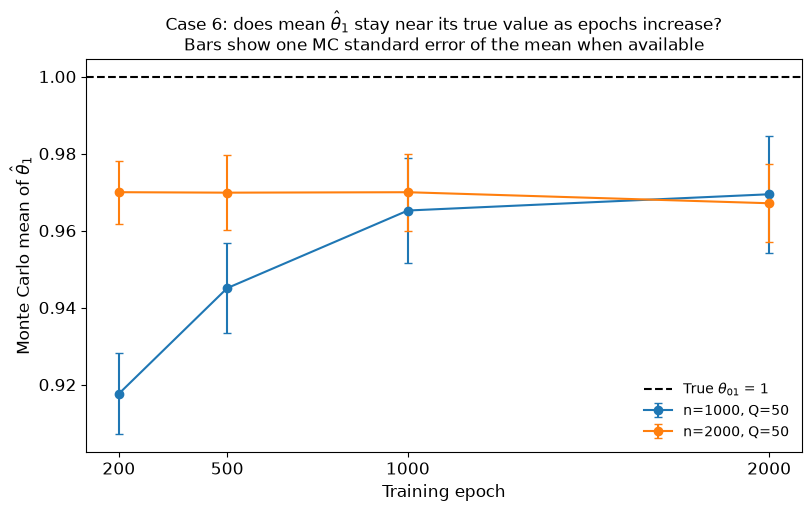

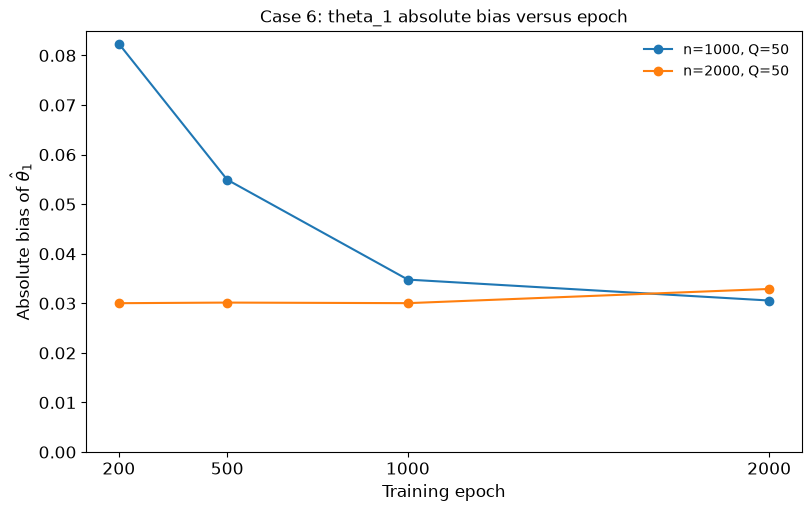

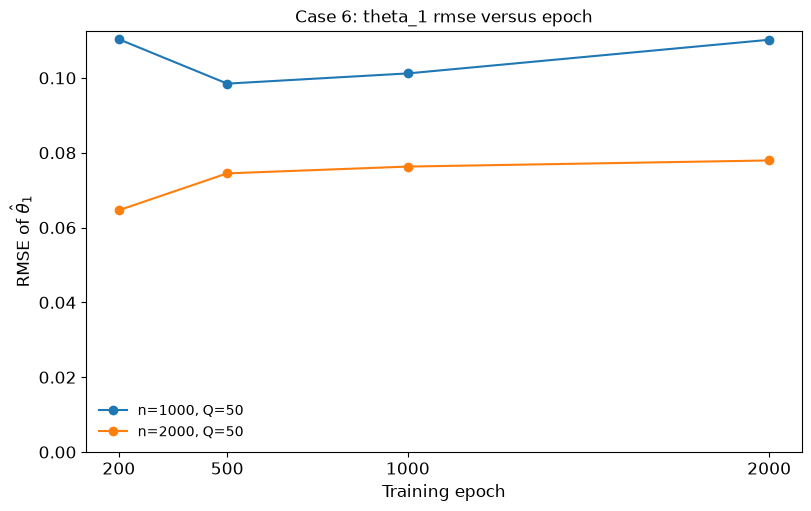

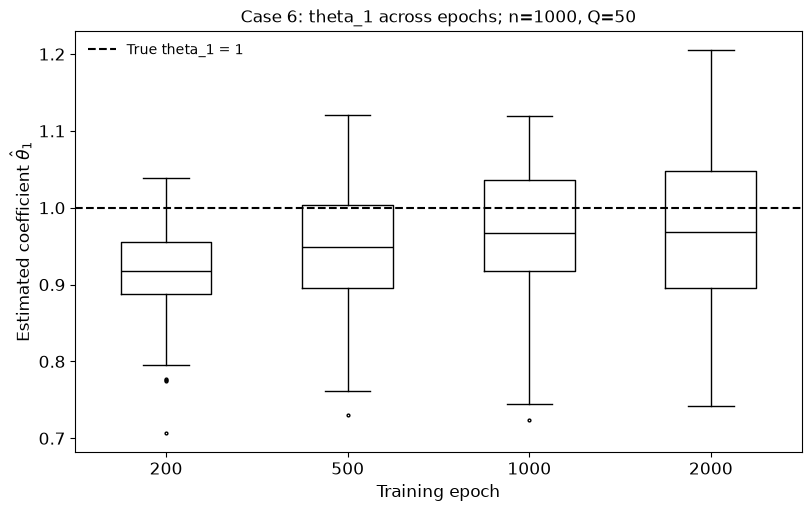

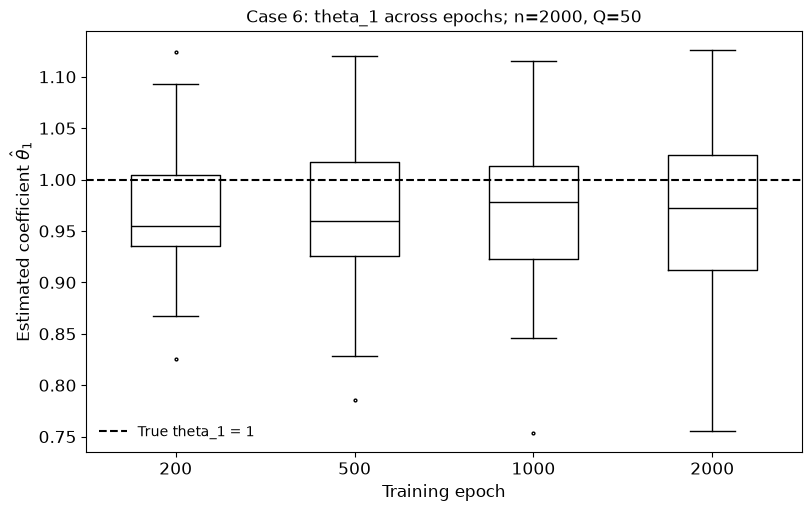

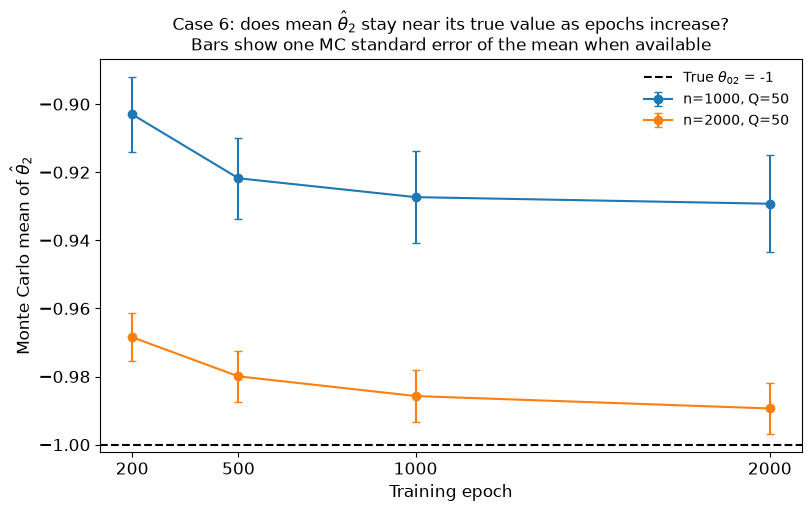

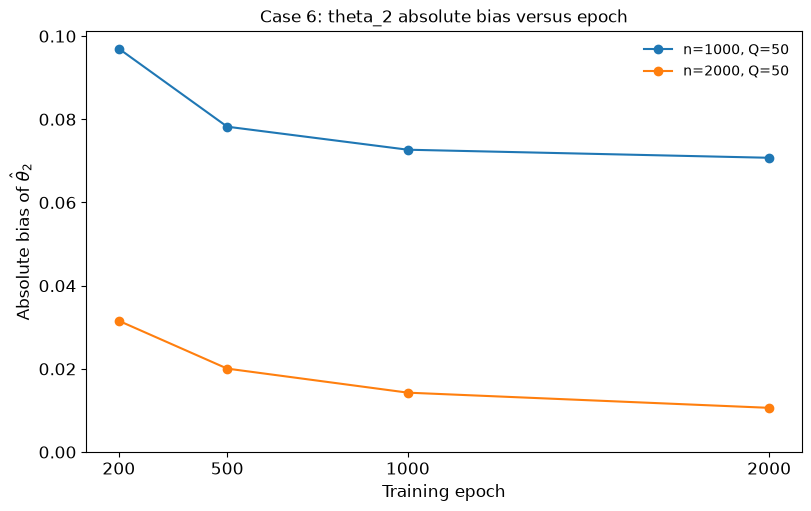

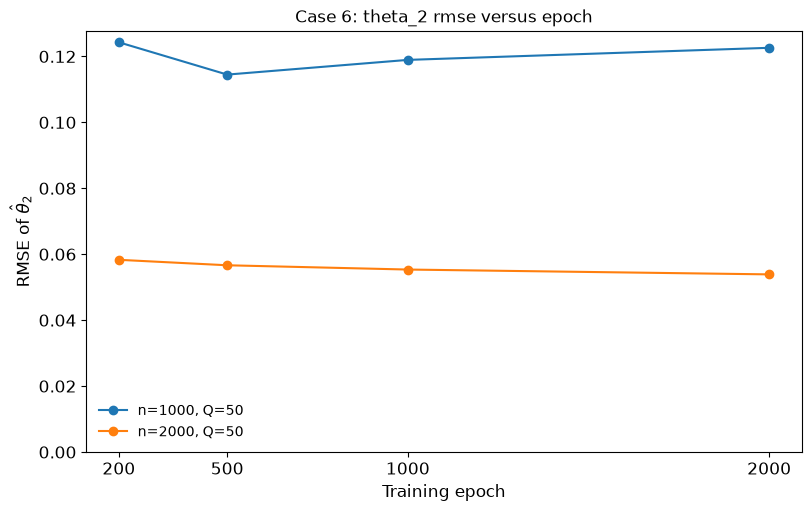

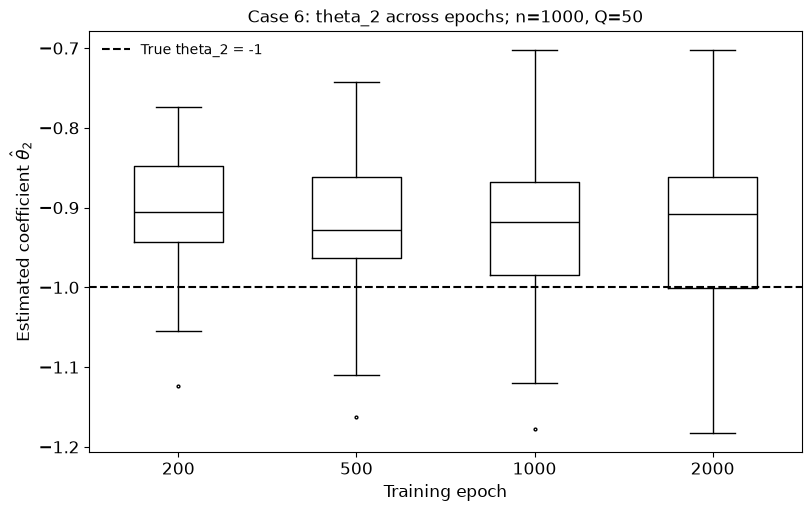

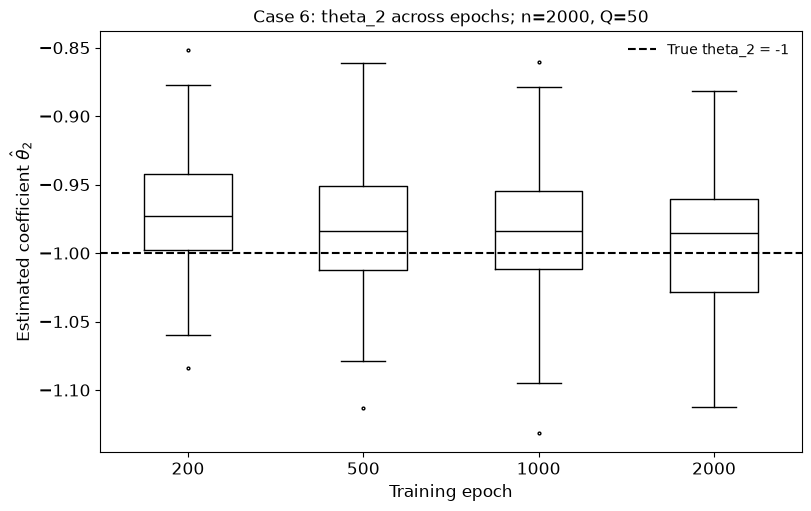

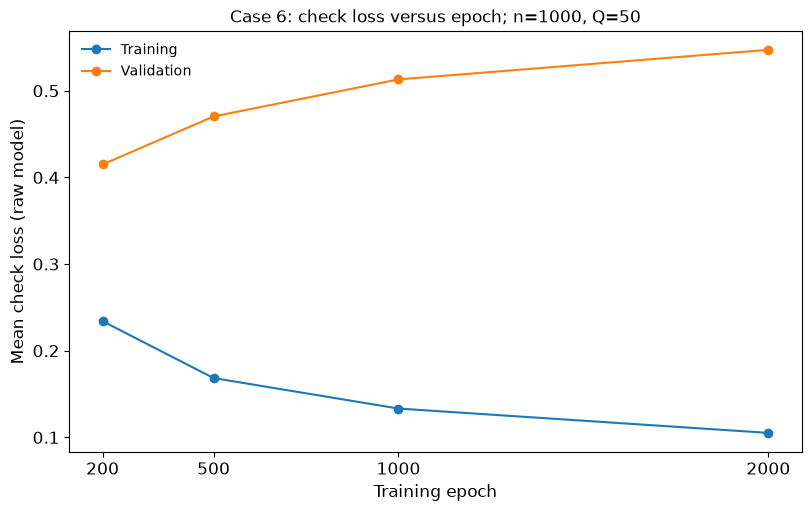

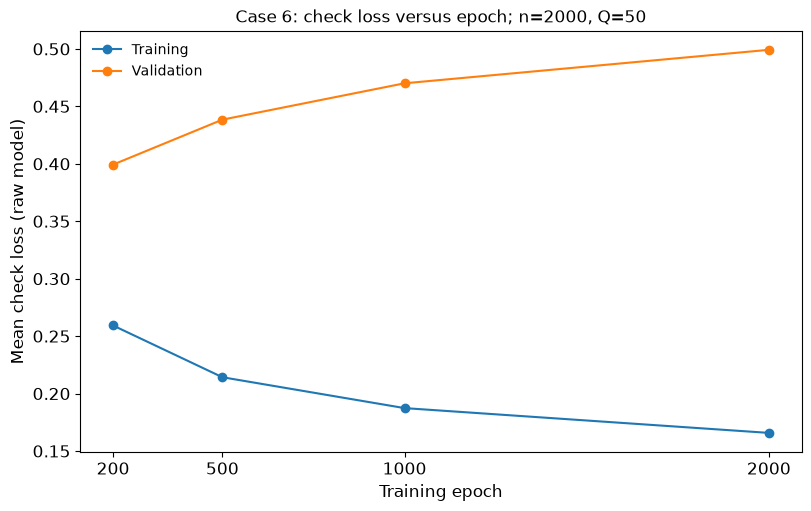

In [11]:
SHOW_MCSE_BARS = True

def save_plot(fig, name):
    figures = OUTPUT / "figures"
    figures.mkdir(exist_ok=True)
    fig.savefig(figures / name, dpi=160, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)

def plot_epoch_diagnostics(frame, table):
    if frame.empty:
        print("No complete trajectories available for plots.")
        return
    colors = {1000: "tab:blue", 2000: "tab:orange"}
    with plt.rc_context({"font.size": 12, "axes.titlesize": 12, "legend.fontsize": 10}):
        for j in (1, 2):
            symbol = rf"$\hat{{\theta}}_{j}$"
            for metric, ylabel, filename in [
                (f"mean_theta{j}", f"Monte Carlo mean of {symbol}", "mean"),
                (f"abs_bias_theta{j}", f"Absolute bias of {symbol}", "absolute_bias"),
                (f"rmse_theta{j}", f"RMSE of {symbol}", "rmse"),
            ]:
                fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
                for n_total in N_LIST:
                    group = table.loc[table.n_total == n_total].sort_values("epoch")
                    if group.empty:
                        continue
                    q = int(group.Q_available.iloc[0])
                    label = f"n={n_total}, Q={q}"
                    if metric == f"mean_theta{j}" and SHOW_MCSE_BARS and group[f"mcse_mean_theta{j}"].notna().all():
                        ax.errorbar(group.epoch, group[metric], yerr=group[f"mcse_mean_theta{j}"],
                                    marker="o", capsize=3, color=colors[n_total], label=label)
                    else:
                        ax.plot(group.epoch, group[metric], marker="o", color=colors[n_total], label=label)
                if metric == f"mean_theta{j}":
                    ax.axhline(THETA_0[j - 1], color="black", ls="--",
                               label=rf"True $\theta_{{0{j}}}$ = {THETA_0[j - 1]:g}")
                    title = f"Case 6: does mean {symbol} stay near its true value as epochs increase?"
                    if SHOW_MCSE_BARS:
                        title += "\nBars show one MC standard error of the mean when available"
                else:
                    ax.set_ylim(bottom=0)
                    title = f"Case 6: theta_{j} {filename.replace('_', ' ')} versus epoch"
                ax.set(xlabel="Training epoch", ylabel=ylabel, xticks=CHECKPOINT_EPOCHS, title=title)
                ax.legend(frameon=False)
                save_plot(fig, f"theta{j}_{filename}_vs_epoch.png")

            for n_total in N_LIST:
                group = frame.loc[frame.n_total == n_total]
                if group.empty:
                    continue
                values = [group.loc[group.epoch == epoch, f"theta_hat_{j}"].to_numpy()
                          for epoch in CHECKPOINT_EPOCHS]
                fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
                positions = np.arange(1, len(CHECKPOINT_EPOCHS) + 1)
                ax.boxplot(values, positions=positions, widths=.5, medianprops={"color": "black"},
                           flierprops={"marker": ".", "markersize": 4})
                ax.set_xticks(positions, [str(e) for e in CHECKPOINT_EPOCHS])
                ax.axhline(THETA_0[j - 1], color="black", ls="--", label=f"True theta_{j} = {THETA_0[j - 1]:g}")
                ax.set(xlabel="Training epoch", ylabel=f"Estimated coefficient {symbol}",
                       title=f"Case 6: theta_{j} across epochs; n={n_total}, Q={len(values[0])}")
                ax.legend(frameon=False)
                save_plot(fig, f"theta{j}_n{n_total}_boxplots.png")

        for n_total in N_LIST:
            group = table.loc[table.n_total == n_total].sort_values("epoch")
            if group.empty:
                continue
            fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
            ax.plot(group.epoch, group.mean_train_check_loss, marker="o", label="Training")
            ax.plot(group.epoch, group.mean_validation_check_loss, marker="o", label="Validation")
            ax.set(xlabel="Training epoch", ylabel="Mean check loss (raw model)", xticks=CHECKPOINT_EPOCHS,
                   title=f"Case 6: check loss versus epoch; n={n_total}, Q={int(group.Q_available.iloc[0])}")
            ax.legend(frameon=False)
            save_plot(fig, f"n{n_total}_check_loss_vs_epoch.png")

plot_epoch_diagnostics(plot_raw, plot_summary)

## 11. Paired trajectory movement relative to epoch 200

For each replication compute $\hat\theta_j(e)-\hat\theta_j(200)$ at e=500,1000,2000.
The plot shows the mean **within-replication change**, with one paired MC SE.
The CSV also includes the mean change in absolute coefficient error and in training/validation loss.
A positive signed movement need not be movement away from truth; use the change in absolute error
and the primary bias plots to assess direction.

Interpretation after running:
- Does mean theta move toward or away from its true reference as training continues?
- Does lower training loss coincide with increased bias or RMSE?
- Is that pattern larger at n=1000 or n=2000, and is it large relative to MC uncertainty?
- Smaller errors at larger n are finite-sample evidence, not a mathematical proof of asymptotic consistency.
No conclusions or numerical results are prefilled in this notebook.

,n_total,epoch,Q_paired,mean_delta_theta1,mcse_delta_theta1,mean_delta_abs_error_theta1,mean_delta_theta2,mcse_delta_theta2,mean_delta_abs_error_theta2,mean_delta_train_check_loss,mean_delta_validation_check_loss
0,1000,500,50,0.02744,0.00620,-0.01441,-0.01877,0.00628,-0.01440,-0.06563,0.05536
1,1000,1000,50,0.04760,0.00986,-0.00889,-0.02431,0.00872,-0.00813,-0.10082,0.09815
2,1000,2000,50,0.05181,0.01324,0.00105,-0.02624,0.01035,-0.00602,-0.12893,0.13227
3,2000,500,50,-0.00012,0.00456,0.00836,-0.01149,0.00381,-0.00108,-0.04503,0.03912
4,2000,1000,50,-0.00001,0.00597,0.00640,-0.01728,0.00495,-0.00252,-0.07191,0.07079
5,2000,2000,50,-0.00287,0.00684,0.00908,-0.02093,0.00589,-0.00111,-0.09349,0.09992


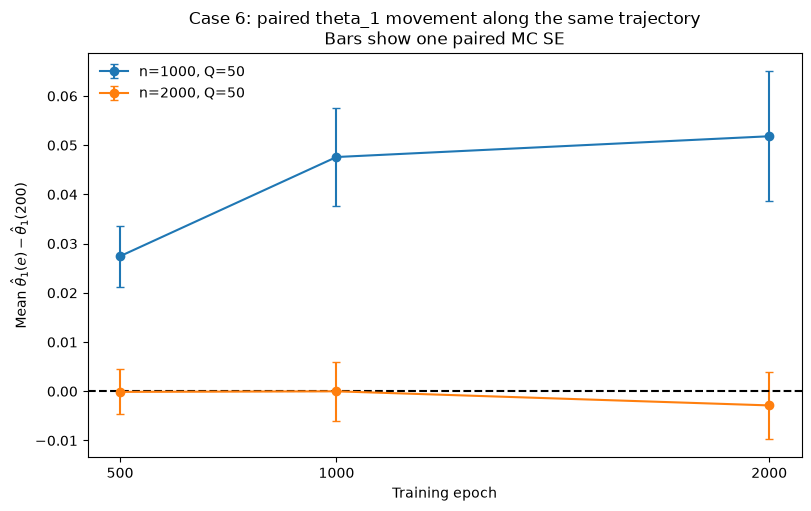

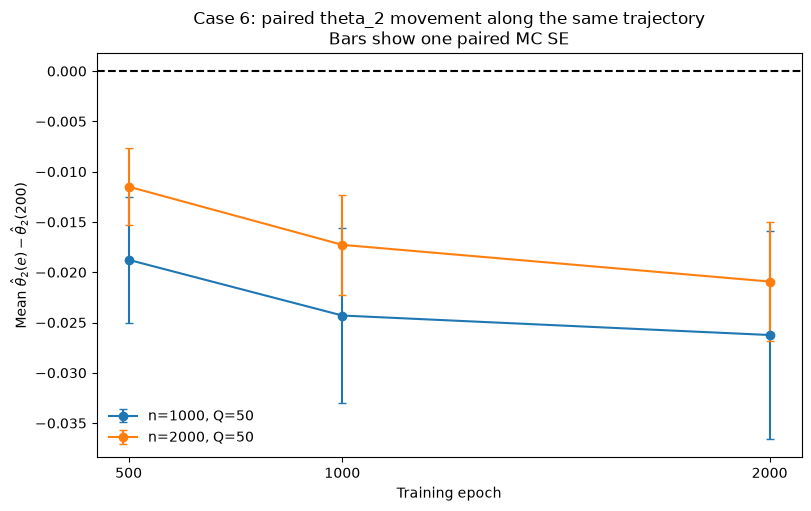

In [12]:
def paired_diagnostic(frame):
    if frame.empty:
        return pd.DataFrame(), pd.DataFrame()
    columns = ["n_total", "replication", "theta_hat_1", "theta_hat_2",
               "train_check_loss", "validation_check_loss"]
    baseline = frame.loc[frame.epoch == 200, columns].rename(
        columns={name: name + "_at_200" for name in columns if name not in ("n_total", "replication")})
    paired = frame.loc[frame.epoch > 200].merge(baseline, on=["n_total", "replication"],
                                              how="inner", validate="many_to_one")
    for j in (1, 2):
        paired[f"delta_theta{j}"] = paired[f"theta_hat_{j}"] - paired[f"theta_hat_{j}_at_200"]
        paired[f"delta_abs_error_theta{j}"] = (
            (paired[f"theta_hat_{j}"] - THETA_0[j - 1]).abs()
            - (paired[f"theta_hat_{j}_at_200"] - THETA_0[j - 1]).abs())
    for name in ("train_check_loss", "validation_check_loss"):
        paired[f"delta_{name}"] = paired[name] - paired[f"{name}_at_200"]
    rows = []
    for (n_total, epoch), group in paired.groupby(["n_total", "epoch"], sort=True):
        row = dict(n_total=int(n_total), epoch=int(epoch), Q_paired=len(group))
        for j in (1, 2):
            row[f"mean_delta_theta{j}"] = float(group[f"delta_theta{j}"].mean())
            row[f"mcse_delta_theta{j}"] = float(group[f"delta_theta{j}"].std(ddof=1) / np.sqrt(len(group))) if len(group)>1 else np.nan
            row[f"mean_delta_abs_error_theta{j}"] = float(group[f"delta_abs_error_theta{j}"].mean())
        row["mean_delta_train_check_loss"] = float(group.delta_train_check_loss.mean())
        row["mean_delta_validation_check_loss"] = float(group.delta_validation_check_loss.mean())
        rows.append(row)
    return paired, pd.DataFrame(rows)

paired_rows, paired_summary = paired_diagnostic(plot_raw)
if paired_summary.empty:
    print("No complete paired trajectories yet.")
else:
    atomic_write(OUTPUT / "paired_changes.csv", paired_rows, "csv")
    atomic_write(OUTPUT / "paired_summary.csv", paired_summary, "csv")
    display(paired_summary.round(5))
    for j in (1, 2):
        fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
        for n_total in N_LIST:
            group = paired_summary.loc[paired_summary.n_total == n_total].sort_values("epoch")
            if group.empty:
                continue
            errors = group[f"mcse_delta_theta{j}"].to_numpy()
            ax.errorbar(group.epoch, group[f"mean_delta_theta{j}"],
                        yerr=errors if np.isfinite(errors).all() else None,
                        marker="o", capsize=3, label=f"n={n_total}, Q={int(group.Q_paired.iloc[0])}")
        ax.axhline(0, color="black", ls="--")
        ax.set(xlabel="Training epoch", xticks=CHECKPOINT_EPOCHS[1:],
               ylabel=rf"Mean $\hat{{\theta}}_{j}(e)-\hat{{\theta}}_{j}(200)$",
               title=f"Case 6: paired theta_{j} movement along the same trajectory\nBars show one paired MC SE")
        ax.legend(frameon=False)
        save_plot(fig, f"theta{j}_paired_change_from_200.png")

## 12. Optional oracle density and weighted projection

**Secondary diagnostics only.** Nothing in this section enters the main training loop.
Leave \`RUN_ORACLE=False\` to skip the calculation. The original latent training $G_{1:8}$
is regenerated and retained by \`make_case6\`; no inverse-CDF reconstruction or projection network is used.

Let $s(z)=\Phi(\operatorname{mean}(z-1))$, $c=2/(\pi\sqrt3)$ and
$\sigma(X,z)=s(z)+0.2X_1$. Then $f_0(U)=c/\sigma(U)$ and
$$\varphi^*(z)=\frac{E[X/\sigma(X,z)\mid z]}{E[1/\sigma(X,z)\mid z]}.$$

Conditional on $G_{1:8}=g$, the means of $(G_9,G_{10})$ are $\mu=\sum g_j/9$, their
variances are $v=5/9$ and covariance $a=1/18$. In particular,
$$G_{10}\mid G_9=h,g\sim N\left(\mu+\tfrac1{10}(h-\mu),\,\tfrac{11}{20}\right).$$

We **integrate out $G_{10}$ analytically** and deterministically integrate $G_9$ over $(0,\infty)$.
This is an equivalent Gaussian integration method to 2D quadrature, and it avoids placing quadrature
nodes across the discontinuity of $1\{G_9>0\}$. Define
$$p=P(G_9>0\mid g)=\Phi(\mu/\sqrt v),\qquad
b=E[X_2\mid g]=2\Phi(\mu/\sqrt{1+v}),$$
$$J=E[X_2 1\{G_9>0\}\mid g]
=\int_0^\infty 2\Phi\left(\frac{\mu+(h-\mu)/10}{\sqrt{1+11/20}}\right)
\frac{\phi((h-\mu)/\sqrt v)}{\sqrt v}\,dh.$$
Then
$$D=\frac{1-p}{s}+\frac{p}{s+0.2},\qquad
N_1=\frac{p}{s+0.2},\qquad
N_2=\frac{b-J}{s}+\frac{J}{s+0.2},\qquad
\varphi^*=(N_1/D,N_2/D).$$
The integration uses \`scipy.integrate.quad_vec\` with one worker and specified tight tolerances,
checks its convergence status and records its error estimate. It makes no random draws.

In [13]:
ORACLE_QUAD_EPSABS = 1e-10
ORACLE_QUAD_EPSREL = 1e-9
ORACLE_QUAD_BATCH = 128

def f0_true(x_raw, z_raw):
    return (2 / (np.pi * np.sqrt(3))) / case6_sigma(x_raw, z_raw)

def oracle_varphi_case6(z_raw, latent_g):
    z_raw, latent_g = np.asarray(z_raw, dtype=float), np.asarray(latent_g, dtype=float)
    if z_raw.shape != latent_g.shape or z_raw.ndim != 2 or z_raw.shape[1] != 8:
        raise ValueError("Expected matching raw Z and latent G arrays of shape (n,8).")
    if not np.isfinite(z_raw).all() or not np.isfinite(latent_g).all():
        raise ValueError("Non-finite oracle inputs.")
    if np.any((z_raw < 0) | (z_raw > 2)):
        raise ValueError("Use raw Z, not StandardScaler-transformed inputs.")
    np.testing.assert_allclose(z_raw, 2 * norm.cdf(latent_g), rtol=1e-12, atol=1e-12)
    v, a = 5/9, 1/18
    sd = np.sqrt(v)
    beta = a / v
    conditional_variance = v - a*a/v
    phi = np.empty((len(z_raw), 2))
    maximum_error = 0.0
    for start in range(0, len(z_raw), ORACLE_QUAD_BATCH):
        stop = min(start + ORACLE_QUAD_BATCH, len(z_raw))
        mu = latent_g[start:stop].sum(axis=1) / 9
        s = norm.cdf(np.mean(z_raw[start:stop] - 1, axis=1))
        p = norm.cdf(mu / sd)
        b = 2 * norm.cdf(mu / np.sqrt(1 + v))

        def integrand(h):
            conditional_x2 = 2 * norm.cdf((mu + beta*(h-mu)) / np.sqrt(1 + conditional_variance))
            return conditional_x2 * norm.pdf((h-mu)/sd) / sd

        joint, error, info = quad_vec(
            integrand, 0.0, np.inf, epsabs=ORACLE_QUAD_EPSABS, epsrel=ORACLE_QUAD_EPSREL,
            norm="max", workers=1, limit=1000, full_output=True,
        )
        if not info.success or not np.isfinite(joint).all():
            raise RuntimeError(f"Oracle integration failed: {info.message}")
        maximum_error = max(maximum_error, float(error))
        denominator = (1-p)/s + p/(s+0.2)
        phi[start:stop, 0] = (p/(s+0.2)) / denominator
        phi[start:stop, 1] = ((b-joint)/s + joint/(s+0.2)) / denominator
    tolerance = 1e-8
    assert np.isfinite(phi).all() and phi.shape == (len(z_raw), 2)
    assert np.all((phi[:, 0] >= -tolerance) & (phi[:, 0] <= 1+tolerance))
    assert np.all((phi[:, 1] >= -tolerance) & (phi[:, 1] <= 2+tolerance))
    # Remove only possible floating-point excursions beyond the exact conditional-mean support.
    phi = np.clip(phi, [0, 0], [1, 2])
    return phi, maximum_error

## 13. Oracle-nuisance asymptotic diagnostic

This is **not** Zhong-Wang's practical heteroscedastic variance estimator. It is an optional
population-nuisance diagnostic evaluated on each regenerated fitting sample. It does not
alter theta, fit any network, or bootstrap.

With $\widetilde X_i=X_i-\varphi^*(Z_i)$, use **uncentered empirical second moments**:
$$\widehat\Sigma_1=\frac{\tau(1-\tau)}{n_{\rm fit}}\sum_i\widetilde X_i\widetilde X_i^\top,\qquad
\widehat\Sigma_2=\frac1{n_{\rm fit}}\sum_i f_0(U_i)\widetilde X_i\widetilde X_i^\top,$$
$$V_{\rm oracle}=\widehat\Sigma_2^{-1}\widehat\Sigma_1\widehat\Sigma_2^{-1},\qquad
Z_j=\frac{\sqrt{n_{\rm fit}}(\hat\theta_j-\theta_{0j})}{\sqrt{V_{{\rm oracle},jj}}}.$$
These are the requested heteroskedastic sandwich moments; do not substitute a centered sample
covariance or the homoskedastic Case 3 scalar-density formula. The weighted projection need not
make the **unweighted** mean residual zero.

The denominator uses the **actual fitting sample size**. Its oracle matrix is the same at every
checkpoint within a replication, so only the raw estimate changes. Oracle outputs are saved under a
separate \`run/oracle_diagnostics/\` directory; repeated optional runs use a fresh subdirectory.

In [14]:
def oracle_covariance(data):
    phi, quadrature_error = oracle_varphi_case6(data.z_train, data.latent_train)
    v = data.x_train - phi
    f0 = f0_true(data.x_train, data.z_train)
    sigma1 = TAU * (1 - TAU) * (v.T @ v) / data.n_fit
    sigma2 = v.T @ (f0[:, None] * v) / data.n_fit
    for matrix in (sigma1, sigma2):
        np.testing.assert_allclose(matrix, matrix.T, rtol=1e-12, atol=1e-14)
        if np.linalg.eigvalsh(matrix).min() <= 0:
            raise FloatingPointError("Oracle sandwich matrix is not positive definite.")
    inverse2 = np.linalg.inv(sigma2)
    covariance = inverse2 @ sigma1 @ inverse2.T
    covariance = (covariance + covariance.T) / 2
    if not np.isfinite(covariance).all() or np.linalg.eigvalsh(covariance).min() <= 0:
        raise FloatingPointError("Invalid oracle asymptotic covariance.")
    diagnostics = dict(n_total=data.n_total, replication=data.replication, n_fit=data.n_fit,
        data_sha256=data.data_sha256, quadrature_max_abs_error=quadrature_error,
        sigma1_min_eigenvalue=float(np.linalg.eigvalsh(sigma1).min()),
        sigma2_min_eigenvalue=float(np.linalg.eigvalsh(sigma2).min()),
        sigma1_condition=float(np.linalg.cond(sigma1)), sigma2_condition=float(np.linalg.cond(sigma2)),
        mean_f0=float(f0.mean()), mean_phi1=float(phi[:, 0].mean()), mean_phi2=float(phi[:, 1].mean()))
    for name, matrix in (("Sigma1", sigma1), ("Sigma2", sigma2), ("V_oracle", covariance)):
        for i, j in ((0, 0), (0, 1), (1, 1)):
            diagnostics[f"{name}_{i+1}{j+1}"] = float(matrix[i, j])
    return covariance, diagnostics

def run_oracle_diagnostic():
    frame = read_saved_results()
    if frame.empty:
        print("No saved point estimates available for the optional diagnostic.")
        return None
    original_theta = frame[["theta_hat_1", "theta_hat_2"]].copy()
    sample_rows = []
    for (n_total, replication), group in frame.groupby(["n_total", "replication"], sort=True):
        data = make_case6(int(n_total), int(replication))
        assert group.data_sha256.eq(data.data_sha256).all()
        assert group.n_fit.eq(data.n_fit).all()
        covariance, diagnostics = oracle_covariance(data)
        for j in (1, 2):
            diagnostics[f"oracle_se_{j}"] = float(np.sqrt(covariance[j-1, j-1] / data.n_fit))
        sample_rows.append(diagnostics)
    sample_table = pd.DataFrame(sample_rows)
    oracle_raw = frame.merge(sample_table[["n_total", "replication", "oracle_se_1", "oracle_se_2"]],
                             on=["n_total", "replication"], how="left", validate="many_to_one", sort=False)
    pd.testing.assert_frame_equal(oracle_raw[["theta_hat_1", "theta_hat_2"]], original_theta, check_exact=True)
    for j in (1, 2):
        oracle_raw[f"Z_oracle_{j}"] = (oracle_raw[f"theta_hat_{j}"] - THETA_0[j-1]) / oracle_raw[f"oracle_se_{j}"]
        assert np.isfinite(oracle_raw[f"Z_oracle_{j}"]).all()
        assert oracle_raw.groupby(["n_total", "replication"])[f"oracle_se_{j}"].nunique().eq(1).all()
    records = []
    for (n_total, epoch), group in oracle_raw.groupby(["n_total", "epoch"], sort=True):
        for j in (1, 2):
            records.append(dict(n_total=int(n_total), n_fit=int(group.n_fit.iloc[0]), epoch=int(epoch),
                component=f"theta_{j}", Q_available=len(group),
                mean_oracle_SE=float(group[f"oracle_se_{j}"].mean()),
                mean_Z_oracle=float(group[f"Z_oracle_{j}"].mean()),
                SD_Z_oracle=float(group[f"Z_oracle_{j}"].std(ddof=1)) if len(group)>1 else np.nan))
    oracle_summary = pd.DataFrame(records)
    base = OUTPUT / "oracle_diagnostics"
    if base.exists() and any(base.iterdir()):
        from datetime import datetime, timezone
        destination = base / ("rerun_" + datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ"))
    else:
        destination = base
    destination.mkdir(parents=True, exist_ok=False if destination != base else True)
    for name, table in (("oracle_replications.csv", oracle_raw), ("oracle_sample_matrices.csv", sample_table),
                         ("oracle_summary.csv", oracle_summary)):
        with (destination / name).open("x", encoding="utf-8", newline="") as stream:
            table.to_csv(stream, index=False)
    with (destination / "oracle_config.json").open("x", encoding="utf-8") as stream:
        json.dump(dict(parent_fingerprint=FINGERPRINT, tau=TAU, theta=THETA_0.tolist(),
            density="2/(pi*sqrt(3)*sigma(U))", integration="conditional analytic reduction plus deterministic quad_vec",
            epsabs=ORACLE_QUAD_EPSABS, epsrel=ORACLE_QUAD_EPSREL, batch=ORACLE_QUAD_BATCH,
            normalization="uncentered moments divided by actual n_fit", training_modified=False), stream, indent=2)
    display(oracle_summary.round(5))
    print("Optional oracle outputs:", destination.relative_to(ROOT))
    return oracle_raw, sample_table, oracle_summary

if RUN_ORACLE:
    oracle_outputs = run_oracle_diagnostic()
else:
    print("Optional oracle-nuisance diagnostic skipped (RUN_ORACLE=False).")

Optional oracle-nuisance diagnostic skipped (RUN_ORACLE=False).


## Reading the eventual results

Check the mean-versus-epoch plots against the true horizontal lines first, then compare absolute bias,
RMSE and paired changes with the check-loss plots. A mean moving away from truth is different from
increased dispersion around an unchanged mean. A lower check loss does not, by itself, imply a more
accurate linear coefficient.

The optional oracle statistic addresses centering and variance scale under the proposed asymptotic
approximation. It is separate from the primary question of raw coefficient movement along the same
optimization path. Finite-sample drift, Monte Carlo uncertainty, architecture/optimization effects and
formal asymptotic consistency must not be conflated.

No simulation results are included in this notebook; every code cell is initially unexecuted.